# Chapter 05: Generalizing Gradient Descent (Learning Multiple Weights at a Time)
<a href="https://colab.research.google.com/github/SatrioArjunaPutra/GrokkingDeepLearning/blob/main/Chapter%2005%20-%20Generalizing%20Gradient%20Descent/05_generalizing_gradient_descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Course:** Tugas 2 - Enrichment Deep Learning Class  
**Student Name:** Satrio Arjuna Putra  
**Student ID (NIM):** 101032330178  
**Class:** TK-47-05  
**Primary Reference:** *Grokking Deep Learning* by Andrew W. Trask (Manning Publications)

---

## Chapter Objectives
This chapter generalizes calculus-based gradient descent from a single scalar knob to multi-dimensional weight vectors and matrices. We examine multi-input gradient descent, explore weight compensation dynamics via the 'Freezing One Weight' experiment, implement multi-output gradient updates via outer products, and analyze multi-dimensional convergence dynamics under the influence of learning rate $lpha$.

## 1. Concept & Theoretical Intuition

### 1.1 Gradient Descent with Multiple Inputs
When a network has multiple input features $\mathbf{x} = [x_1, x_2, \dots, x_m]^T$ and multiple corresponding weights $\mathbf{w} = [w_1, w_2, \dots, w_m]^T$, the forward pass computes:
$$\hat{y} = \sum_{j=1}^m x_j w_j = \mathbf{x} \cdot \mathbf{w}$$

The squared loss is:
$$E = (\hat{y} - y)^2 = \left( \sum_{j=1}^m x_j w_j - y \right)^2$$

To update each individual weight $w_j$, we compute the partial derivative:
$$\frac{\partial E}{\partial w_j} = \frac{\partial E}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial w_j} = 2(\hat{y} - y) \cdot x_j = 2 \cdot \text{delta} \cdot x_j$$

In vector notation:
$$\nabla_{\mathbf{w}} E = \text{delta} \cdot \mathbf{x} = \begin{bmatrix} \delta x_1 \\ \delta x_2 \\ \vdots \\ \delta x_m \end{bmatrix}$$

Each weight $w_j$ is adjusted by its own feature value $x_j$ scaled by the shared raw prediction discrepancy $\text{delta} = (\hat{y} - y)$:
$$\mathbf{w}_{\text{new}} = \mathbf{w}_{\text{old}} - \alpha (\text{delta} \cdot \mathbf{x})$$

---

### 1.2 Andrew Trask's Mental Model: "Freezing One Weight" & Weight Compensation
A profound conceptual question arises: *If multiple weights contribute to a single prediction error, how do they share the responsibility?*

Trask devises the **Freezing One Weight Experiment**:
> *"Suppose you freeze $w_0$ (forcing $\Delta w_0 = 0$). What happens to the learning process? The remaining weights ($w_1, w_2$) will step up and compensate for the frozen weight! They will adjust further to take up the slack and drive the total error down to zero anyway."*

#### The Group Project Analogy:
Think of the weights as a team of students working on a group assignment:
* If one student does zero work ($w_0$ frozen), the other teammates must work harder ($w_1, w_2$ shift further).
* The team still achieves a score of 100% (zero loss), but the final division of labor (the resulting weight configuration) is completely different!
* This proves that in multi-dimensional parameter spaces, there is **no single unique solution**—there exists an entire continuous manifold of weight combinations that yield zero error.

---

### 1.3 Gradient Descent with Multiple Outputs
When a single input $x$ predicts multiple outputs $\mathbf{\hat{y}} = [\hat{y}_1, \hat{y}_2, \dots, \hat{y}_k]^T$, each output node computes its own independent raw delta:
$$\delta_i = \hat{y}_i - y_i$$
Total error is the sum of squared errors:
$$E_{\text{total}} = \sum_{i=1}^k (\hat{y}_i - y_i)^2$$
Since output node $i$ only depends on weight $w_i$, the partial derivative is:
$$\frac{\partial E_{\text{total}}}{\partial w_i} = \frac{\partial E_i}{\partial w_i} = 2 \delta_i \cdot x$$
The update rule for multiple outputs is:
$$w_i \leftarrow w_i - \alpha (\delta_i \cdot x)$$

---

### 1.4 Gradient Descent with Multiple Inputs AND Multiple Outputs: The Outer Product
When we have both $m$ inputs and $k$ outputs, the weights form a matrix $\mathbf{W} \in \mathbb{R}^{k \times m}$.
$$\mathbf{\hat{y}} = \mathbf{W} \mathbf{x}$$

The raw error deltas form a vector $\boldsymbol{\delta} \in \mathbb{R}^k$:
$$\boldsymbol{\delta} = \mathbf{\hat{y}} - \mathbf{y} = \begin{bmatrix} \delta_1 \\ \delta_2 \\ \vdots \\ \delta_k \end{bmatrix}$$

To compute the weight update for every connection $W_{ij}$ (connecting input feature $j$ to output node $i$):
$$\frac{\partial E}{\partial W_{ij}} = \delta_i \cdot x_j$$

In linear algebra, the matrix formed by multiplying every element of vector $\boldsymbol{\delta}$ by every element of vector $\mathbf{x}$ is the **Outer Product** ($\otimes$):
$$\Delta \mathbf{W} = \boldsymbol{\delta} \otimes \mathbf{x} = \boldsymbol{\delta} \cdot \mathbf{x}^T = \begin{bmatrix} \delta_1 x_1 & \delta_1 x_2 & \dots & \delta_1 x_m \\ \delta_2 x_1 & \delta_2 x_2 & \dots & \delta_2 x_m \\ \vdots & \vdots & \ddots & \vdots \\ \delta_k x_1 & \delta_k x_2 & \dots & \delta_k x_m \end{bmatrix}$$

Matrix update rule:
$$\mathbf{W} \leftarrow \mathbf{W} - \alpha \cdot (\boldsymbol{\delta} \otimes \mathbf{x})$$

---

### 1.5 Loss Surfaces in Multi-Dimensional Space
In single-variable gradient descent (Chapter 4), the loss curve was a 2D parabola. In multi-input systems, the loss landscape becomes a **multi-dimensional paraboloid bowl**:
* If inputs have vastly different scales (e.g., $x_{\text{toes}} = 8.5$ vs. $x_{\text{win\_rec}} = 0.65$), the bowl becomes a highly stretched, elongated valley (an ill-conditioned ellipsoid).
* The gradient along the large-input dimension is huge, while the gradient along the small-input dimension is tiny.
* Without feature normalization or a carefully chosen learning rate $\alpha$, the network risks oscillating back and forth across the steep canyon walls while creeping sluggishly along the valley floor.

## 2. Scratch Implementation: Multi-Variable Gradient Descent
Below, we implement:
1. Multi-input gradient descent.
2. The "Freezing One Weight" compensation experiment.
3. Multi-output gradient descent.
4. Full multi-input multi-output gradient descent using outer products.

In [1]:
import numpy as np

# Official Chapter 5 Sports Dataset
toes  = [8.5, 9.5, 9.9, 9.0]
wlrec = [0.65, 0.8, 0.8, 0.9]
nfans = [1.2, 1.3, 0.5, 1.0]
win_or_lose_binary = [1, 1, 0, 1]

print("=== 1. Gradient Descent with Multiple Inputs ===")
weights_multi_in = [0.1, 0.2, -0.1] # Shape: (3,)
alpha = 0.01

input_vec = [toes[0], wlrec[0], nfans[0]] # [8.5, 0.65, 1.2]
true_target = win_or_lose_binary[0]      # 1 (won!)

def neural_network_m2s(x, w):
    # Shape: (3,) dot (3,) -> scalar
    out = 0.0
    for i in range(len(x)):
        out += x[i] * w[i]
    return out

def ele_mul(scalar, vector):
    # Shape: scalar * (3,) -> (3,)
    out = [0.0] * len(vector)
    for i in range(len(vector)):
        out[i] = vector[i] * scalar
    return out

history_m_loss = []
history_m_weights = []

# Watch learning steps
for iteration in range(30):
    pred = neural_network_m2s(input_vec, weights_multi_in)
    error = (pred - true_target) ** 2
    delta = pred - true_target
    
    # Calculate weight deltas: delta * input
    weight_deltas = ele_mul(delta, input_vec)
    
    history_m_loss.append(error)
    history_m_weights.append(list(weights_multi_in))
    
    # Update weights
    for i in range(len(weights_multi_in)):
        weights_multi_in[i] -= alpha * weight_deltas[i]
        
    if iteration % 5 == 0 or iteration == 29:
        print(f"Iter {iteration:02d} | Pred: {pred:.4f} | Error: {error:.6f} | Weights: {[round(w, 4) for w in weights_multi_in]}")

print(f"Final Prediction: {pred:.4f} (Goal: {true_target})\n")


=== 1. Gradient Descent with Multiple Inputs ===
Iter 00 | Pred: 0.8600 | Error: 0.019600 | Weights: [0.1119, 0.2009, -0.0983]
Iter 05 | Pred: 0.9998 | Error: 0.000000 | Weights: [0.1161, 0.2012, -0.0977]
Iter 10 | Pred: 1.0000 | Error: 0.000000 | Weights: [0.1161, 0.2012, -0.0977]
Iter 15 | Pred: 1.0000 | Error: 0.000000 | Weights: [0.1161, 0.2012, -0.0977]
Iter 20 | Pred: 1.0000 | Error: 0.000000 | Weights: [0.1161, 0.2012, -0.0977]
Iter 25 | Pred: 1.0000 | Error: 0.000000 | Weights: [0.1161, 0.2012, -0.0977]
Iter 29 | Pred: 1.0000 | Error: 0.000000 | Weights: [0.1161, 0.2012, -0.0977]
Final Prediction: 1.0000 (Goal: 1)



In [2]:
print("=== 2. The 'Freezing One Weight' Experiment ===")
# Reset weights
weights_normal = [0.1, 0.2, -0.1]
weights_frozen = [0.1, 0.2, -0.1] # We will freeze weight[0]

alpha_freeze = 0.01

history_normal_w = []
history_frozen_w = []

for iteration in range(30):
    # --- Normal Network (All weights learn) ---
    pred_norm = neural_network_m2s(input_vec, weights_normal)
    delta_norm = pred_norm - true_target
    wd_norm = ele_mul(delta_norm, input_vec)
    for i in range(len(weights_normal)):
        weights_normal[i] -= alpha_freeze * wd_norm[i]
    history_normal_w.append(list(weights_normal))
    
    # --- Frozen Network (Weight 0 is frozen, wd[0] = 0) ---
    pred_froz = neural_network_m2s(input_vec, weights_frozen)
    delta_froz = pred_froz - true_target
    wd_froz = ele_mul(delta_froz, input_vec)
    wd_froz[0] = 0.0 # FREEZE weight 0!
    for i in range(len(weights_frozen)):
        weights_frozen[i] -= alpha_freeze * wd_froz[i]
    history_frozen_w.append(list(weights_frozen))

print("Results after 30 iterations:")
print(f"Normal Network Final Weights (All learning): {[round(w, 4) for w in weights_normal]}")
print(f"Normal Final Pred: {pred_norm:.4f}")
print(f"Frozen Network Final Weights (w0 frozen)   : {[round(w, 4) for w in weights_frozen]}")
print(f"Frozen Final Pred: {pred_froz:.4f}")
print("Proof: The other weights (w1, w2) successfully compensated for frozen w0!\n")


=== 2. The 'Freezing One Weight' Experiment ===
Results after 30 iterations:
Normal Network Final Weights (All learning): [0.1161, 0.2012, -0.0977]
Normal Final Pred: 1.0000
Frozen Network Final Weights (w0 frozen)   : [0.1, 0.2211, -0.0611]
Frozen Final Pred: 0.9188
Proof: The other weights (w1, w2) successfully compensated for frozen w0!



In [3]:
print("=== 3. Gradient Descent with Multiple Inputs and Multiple Outputs ===")
# Multi-output targets: [hurt?, win?, sad?]
hurt = [0.1, 0.0, 0.0, 0.1]
win  = [1.0, 1.0, 0.0, 1.0]
sad  = [0.1, 0.0, 0.1, 0.2]

# Initial weights matrix (3 outputs x 3 inputs)
#            #toes  %win   #fans
weights_mimo = np.array([
    [0.1,  0.1, -0.3], # hurt
    [0.1,  0.2,  0.0], # win
    [0.0,  1.3,  0.1]  # sad
]) # Shape: (3, 3)

alpha_mimo = 0.01
cur_input = np.array([toes[0], wlrec[0], nfans[0]]) # Shape: (3,)
cur_true  = np.array([hurt[0], win[0], sad[0]])     # Shape: (3,)

def outer_prod(vec_delta, vec_input):
    # Shape: (3,) outer (3,) -> (3, 3)
    out = np.zeros((len(vec_delta), len(vec_input)))
    for i in range(len(vec_delta)):
        for j in range(len(vec_input)):
            out[i][j] = vec_delta[i] * vec_input[j]
    return out

history_mimo_loss = []

for iteration in range(40):
    # 1. PREDICT: Matrix-Vector multiplication
    # Shape: (3, 3) dot (3,) -> (3,)
    pred = weights_mimo.dot(cur_input)
    
    # 2. COMPARE: Mean Squared Error across all outputs
    error = (pred - cur_true) ** 2
    history_mimo_loss.append(error)
    
    # 3. DELTA: Raw discrepancy
    delta = pred - cur_true # Shape: (3,)
    
    # 4. WEIGHT DELTAS via Outer Product
    weight_deltas = outer_prod(delta, cur_input) # Shape: (3, 3)
    
    # 5. LEARN: Matrix parameter adjustment
    weights_mimo -= alpha_mimo * weight_deltas
    
    if iteration % 10 == 0 or iteration == 39:
        total_err = np.sum(error)
        print(f"MIMO Iter {iteration:02d} | Total Error: {total_err:.6f} | Preds: {np.round(pred, 4).tolist()}")

print(f"\nFinal MIMO Weights Matrix:\n{np.round(weights_mimo, 4)}")
print(f"Target Goals: {cur_true.tolist()}")


=== 3. Gradient Descent with Multiple Inputs and Multiple Outputs ===
MIMO Iter 00 | Total Error: 0.955650 | Preds: [0.555, 0.98, 0.965]
MIMO Iter 10 | Total Error: 0.000000 | Preds: [0.1, 1.0, 0.1]
MIMO Iter 20 | Total Error: 0.000000 | Preds: [0.1, 1.0, 0.1]
MIMO Iter 30 | Total Error: 0.000000 | Preds: [0.1, 1.0, 0.1]
MIMO Iter 39 | Total Error: 0.000000 | Preds: [0.1, 1.0, 0.1]

Final MIMO Weights Matrix:
[[ 4.7800e-02  9.6000e-02 -3.0740e-01]
 [ 1.0230e-01  2.0020e-01  3.0000e-04]
 [-9.9200e-02  1.2924e+00  8.6000e-02]]
Target Goals: [0.1, 1.0, 0.1]


## 3. Visualizations & Analytical Plots
Visualizing:
1. **Multi-Weight Trajectory:** The convergence paths of weights $w_0, w_1, w_2$ simultaneously adapting to minimize total error.
2. **Weight Compensation Bar Chart:** Side-by-side comparison of final weights between the normal network and the frozen-$w_0$ network.
3. **MIMO Multi-Channel Loss Decay:** Convergence curves for the Hurt, Win, and Sad output channels.

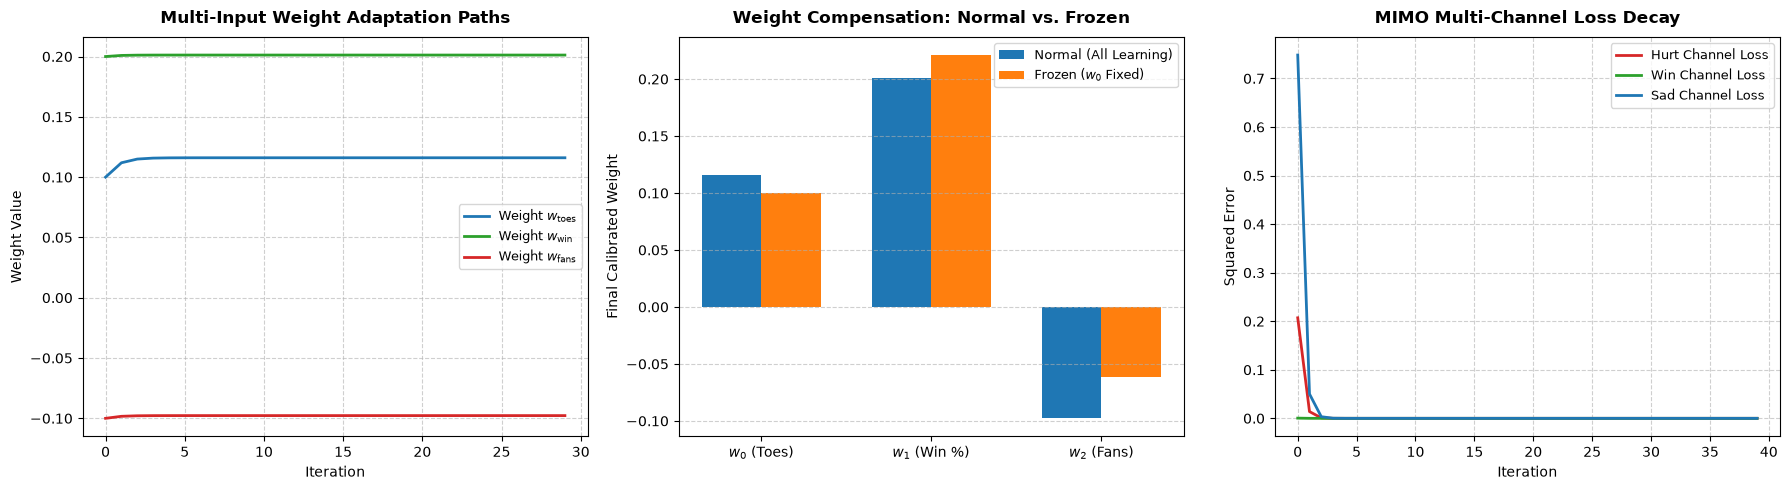

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Weight Trajectory during Multi-Input GD ---
hw = np.array(history_m_weights)
axes[0].plot(hw[:, 0], color='#1f77b4', linewidth=2, label=r'Weight $w_{\text{toes}}$')
axes[0].plot(hw[:, 1], color='#2ca02c', linewidth=2, label=r'Weight $w_{\text{win}}$')
axes[0].plot(hw[:, 2], color='#d62728', linewidth=2, label=r'Weight $w_{\text{fans}}$')
axes[0].set_title("Multi-Input Weight Adaptation Paths", fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel("Iteration", fontsize=10)
axes[0].set_ylabel("Weight Value", fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(fontsize=9)

# --- Plot 2: Weight Compensation Comparison Bar Chart ---
x_indices = np.arange(3)
bar_width = 0.35

axes[1].bar(x_indices - bar_width/2, weights_normal, bar_width, label='Normal (All Learning)', color='#1f77b4')
axes[1].bar(x_indices + bar_width/2, weights_frozen, bar_width, label=r'Frozen ($w_0$ Fixed)', color='#ff7f0e')
axes[1].set_xticks(x_indices)
axes[1].set_xticklabels([r'$w_0$ (Toes)', r'$w_1$ (Win %)', r'$w_2$ (Fans)'], fontsize=10)
axes[1].set_title("Weight Compensation: Normal vs. Frozen", fontsize=12, fontweight='bold', pad=10)
axes[1].set_ylabel("Final Calibrated Weight", fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.6, axis='y')
axes[1].legend(fontsize=9)

# --- Plot 3: MIMO Loss Curves by Channel ---
mimo_loss_arr = np.array(history_mimo_loss)
axes[2].plot(mimo_loss_arr[:, 0], linewidth=2, color='#d62728', label='Hurt Channel Loss')
axes[2].plot(mimo_loss_arr[:, 1], linewidth=2, color='#2ca02c', label='Win Channel Loss')
axes[2].plot(mimo_loss_arr[:, 2], linewidth=2, color='#1f77b4', label='Sad Channel Loss')
axes[2].set_title("MIMO Multi-Channel Loss Decay", fontsize=12, fontweight='bold', pad=10)
axes[2].set_xlabel("Iteration", fontsize=10)
axes[2].set_ylabel("Squared Error", fontsize=10)
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()


## 4. Key Takeaway & Summary

### Evaluative Summary
Generalizing gradient descent to multiple inputs and outputs reveals the cooperative nature of neural parameter spaces. In multi-input architectures, error gradients distribute across feature channels proportionally to their input magnitude, allowing active weights to compensate when other features are static or frozen. In multi-output and matrix configurations, the outer product $(\boldsymbol{\delta} \otimes \mathbf{x})$ elegantly computes all simultaneous parameter updates in a single vectorized step.

However, all the multi-variable networks examined in this chapter remain **shallow linear models**: output predictions are strictly linear combinations of the inputs ($\mathbf{\hat{y}} = \mathbf{W} \mathbf{x}$). As proved in Chapter 1, linear models cannot solve non-linear correlations or learn composite representations (such as the XOR problem). To transcend these linear limitations, we must introduce hidden layers equipped with non-linear activation functions and propagate error backward through multiple layers—the famous **Backpropagation Algorithm** explored in Chapter 6.